## Initial testing
just getting some plots and basic analysis for the initial data we have

In [227]:
import numpy as np
from scipy.optimize import curve_fit
import pandas as pd
import matplotlib.pyplot as plt
from uncertainties import ufloat, unumpy

import Methods as m
import importlib
importlib.reload(m)

<module 'Methods' from '/Users/markzhitnitsky/Desktop/School/2025-26 Year/PHYS409/Experiment 2 - Optical Pumping/Code/Methods.py'>

In [228]:
freq = 195
savename = "5s measurement Mar 9 - " + str(freq) + 'kHz'
time, y1, y2, y2_norm = m.read_transmission_csv('./data/Mar 9 measurement/NewFile' + str(freq) + 'kHz' + '.csv')
bAdjustment =  1.03360784475 # 1.07555537208

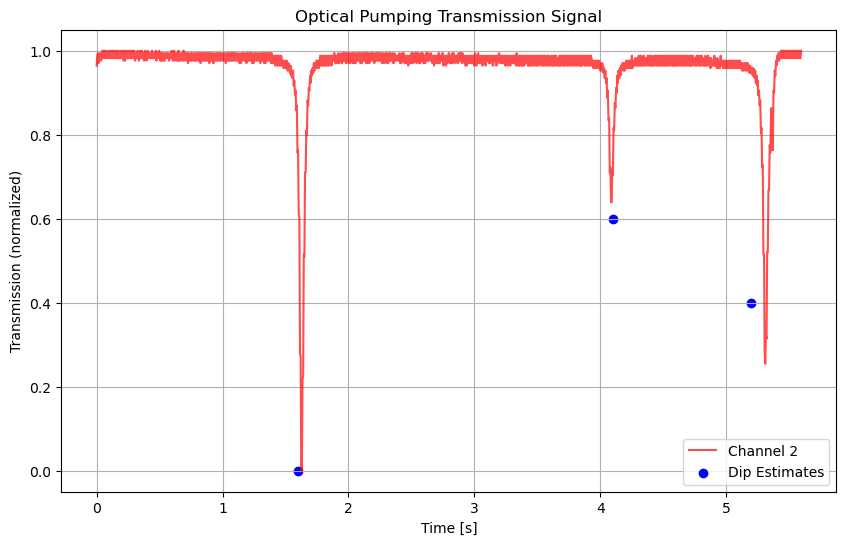

In [229]:
t0 = 0.4
nCut = (t0 // (time[1] - time[0])).astype(int)

time_cutFirst = time[nCut:] - t0
y2_norm_cutFirst = y2_norm[nCut:]

x0s = np.array([1.6,4.1,5.2])

m.plot_normalized_transmission(time_cutFirst, y2_norm_cutFirst, x0s, savename)


In [230]:
#    (A, h1, g1, x0_1, h2, g2, x0_2,  h3, g3, x0_3):
variables = ["A", "h1", "g1", "x0_1", "h2", "g2", "x0_2",  "h3", "g3", "x0_3"]
p0 = (1, 1, 0.3, x0s[0], 0.3, 0.1, x0s[1], 0.5, 0.1, x0s[2])
lower_bound = (0,0,0,0,0,0,0,0,0,0)
upper_bound = (2,2,2,100,2,2,100,2,2,100)
bounds = [lower_bound, upper_bound]
popt, pcov = curve_fit(m.triple_lorentz, time_cutFirst, y2_norm_cutFirst, p0=p0, bounds=bounds)
perr = np.sqrt(np.diag(pcov))
# popt, pcov = curve_fit(multi_lorentz, x, y2)
# print(popt)
for val, name in zip(popt,variables):
    print(name, val)

A 0.982770886889473
h1 0.9758011401492914
g1 0.017287178026518822
x0_1 1.6287321637660965
h2 0.3337275225316002
g2 0.019996122347414175
x0_2 4.088588649787089
h3 0.7149112582219167
g3 0.021025718408526753
x0_3 5.3129501181720356


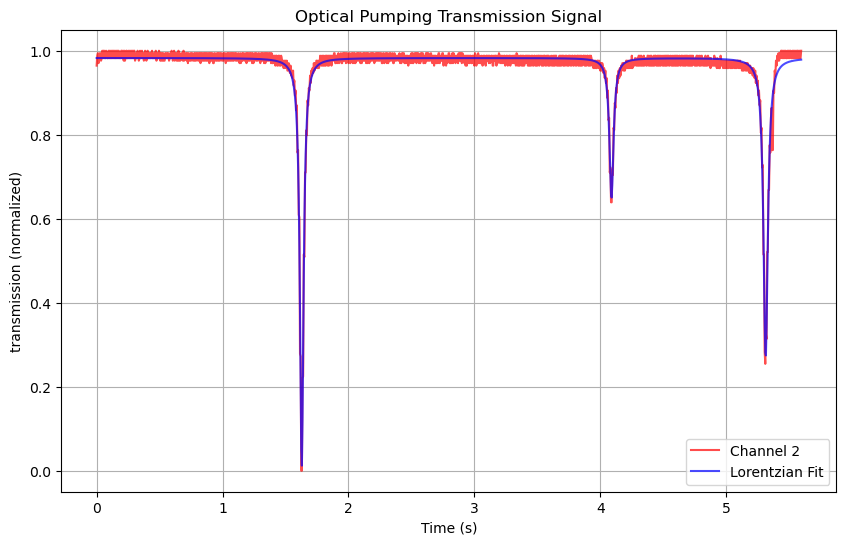

In [231]:
m.plot_fitted_transmission(time_cutFirst, y2_norm_cutFirst, popt, m.triple_lorentz, "fit to " + savename)

In [232]:
x0_1_u = ufloat(popt[3], perr[3]) + t0
x0_2_u = ufloat(popt[6], perr[6]) + t0
x0_3_u = ufloat(popt[9], perr[9]) + t0

# 3. Handle indexing (indices must be integers, so we use n)
dt = time[1] - time[0]
x0_1_index = int(x0_1_u.n // dt)
x0_2_index = int(x0_2_u.n // dt)
x0_3_index = int(x0_3_u.n // dt)

numAvg = 10

# 4. Calculate mean voltages (V) with uncertainty
# We treat the raw data y1 as having some inherent noise (e.g., std dev of the mean)
v_1 = ufloat(np.mean(y1[x0_1_index - numAvg : x0_1_index + numAvg]),
             np.std(y1[x0_1_index - numAvg : x0_1_index + numAvg]))
v_2 = ufloat(np.mean(y1[x0_2_index - numAvg : x0_2_index + numAvg]),
             np.std(y1[x0_2_index - numAvg : x0_2_index + numAvg]))
v_3 = ufloat(np.mean(y1[x0_3_index - numAvg : x0_3_index + numAvg]),
             np.std(y1[x0_3_index - numAvg : x0_3_index + numAvg]))

# 5. Define calibration constant
# Note: if there is uncertainty in the 0.6 factor, you should make it a ufloat too
VtoB = ufloat(0.6 * 10**(-4),0.6 * 10**(-4)/100) * bAdjustment/10 # this factor of 10 is only for measurements up to and including Mar 9

# 6. Calculate B fields (Uncertainties propagate automatically here)
Rb_87 = (v_2 - v_1) * VtoB
Rb_85 = (v_3 - v_1) * VtoB

print(f"v_1: {v_1/10:.3e} V")

print(f"Rb87: {Rb_87:.3e} T")
print(f"Rb85: {Rb_85:.3e} T")

v_1: (3.012+/-0.137)e-01 V
Rb87: (2.803+/-0.128)e-05 T
Rb85: (4.172+/-0.144)e-05 T


In [226]:
filepath = 'models/BFreqRatiosUncertain.csv'

m.append_to_v_ratio_csv(freq, Rb_87, Rb_85, filepath)

In [233]:
freq = 600
vHoriz = 0.055
savename = "5s measurement Mar 20 - " + str(freq) + 'kHz'
time, y1, y2, y2_norm = m.read_transmission_csv('./data/Mar 20 measurement/' + str(freq) + 'kHz_5s.csv')



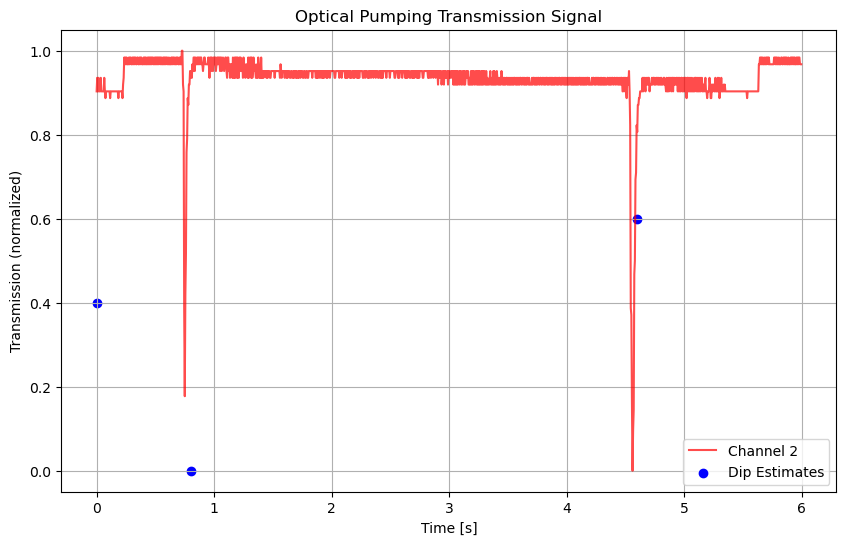

In [234]:
t0 = 0
nCut = (t0 // (time[1] - time[0])).astype(int)

time_cutFirst = time[nCut:] - t0
y2_norm_cutFirst = y2_norm[nCut:]

x0s = np.array([0.8,4.6,0])

m.plot_normalized_transmission(time_cutFirst, y2_norm_cutFirst, x0s, savename)


In [235]:
#    (A, h1, g1, x0_1, h2, g2, x0_2,  h3, g3, x0_3):
variables = ["A", "h1", "g1", "x0_1", "h2", "g2", "x0_2"]
p0 = (1, 1, 0.3, x0s[0], 0.3, 0.1, x0s[1])
lower_bound = (0,0,0,0,0,0,0)
upper_bound = (2,2,2,100,2,2,100)
bounds = [lower_bound, upper_bound]
popt, pcov = curve_fit(m.double_lorentz, time_cutFirst, y2_norm_cutFirst, p0=p0, bounds=bounds)
perr = np.sqrt(np.diag(pcov))
# popt, pcov = curve_fit(multi_lorentz, x, y2)
# print(popt)
for val, name in zip(popt,variables):
    print(name, val)

A 0.9423180140780462
h1 0.801096210028305
g1 0.0063804215833564125
x0_1 0.7511691156218804
h2 0.9688712930897686
g2 0.013457758111835782
x0_2 4.562307244252556


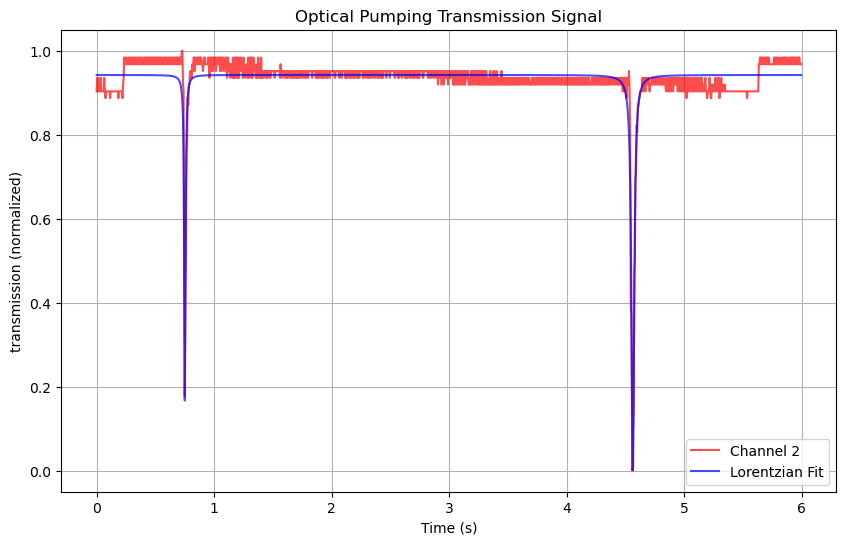

In [236]:
m.plot_fitted_transmission(time_cutFirst, y2_norm_cutFirst, popt, m.double_lorentz, "fit to " + savename)

In [237]:
x0_1_u = ufloat(popt[3], perr[3]) + t0
x0_2_u = ufloat(popt[6], perr[6]) + t0

dt = time[1] - time[0]
x0_1_index = int(x0_1_u.n // dt)
x0_2_index = int(x0_2_u.n // dt)

numAvg = 10

# We treat the raw data y1 as having some inherent noise (e.g., std dev of the mean)
v_1 = ufloat(np.mean(y1[x0_1_index - numAvg : x0_1_index + numAvg]),
             np.std(y1[x0_1_index - numAvg : x0_1_index + numAvg]))
v_2 = ufloat(np.mean(y1[x0_2_index - numAvg : x0_2_index + numAvg]),
             np.std(y1[x0_2_index - numAvg : x0_2_index + numAvg]))


v_0 = ufloat(0.3,0.0034) # taken from 25kHz, though other frequencies were close (this isn't frequency dependent)

# Note: if there is uncertainty in the 0.6 factor, you should make it a ufloat too
VtoB = ufloat(0.6 * 10**(-4),0.6 * 10**(-4) / 100) * bAdjustment
VtoBHoriz = ufloat(1.705174,0.028108) / 1000
# VtoBHoriz = ufloat(1.775151,0.029249) / 1000

Rb_87 = (v_1 - v_0) * VtoB + vHoriz * VtoBHoriz
Rb_85 = (v_2 - v_0) * VtoB + vHoriz * VtoBHoriz

# print(f"v_0: {v_0:.3e} V")

print(f"Rb87: {Rb_87:.3e} T")
print(f"Rb85: {Rb_85:.3e} T")

Rb87: (8.033+/-0.189)e-05 T
Rb85: (1.237+/-0.020)e-04 T


In [238]:
filepath = 'models/BFreqRatiosUncertain.csv'

m.append_to_v_ratio_csv(freq, Rb_87, Rb_85, filepath)

In [239]:
freq = 700
vHoriz = 0.043
savename = "5s measurement Mar 20 - " + str(freq) + 'kHz'
time, y1, y2, y2_norm = m.read_transmission_csv('./data/Mar 20 measurement/' + str(freq) + 'kHz_5s_43.csv')



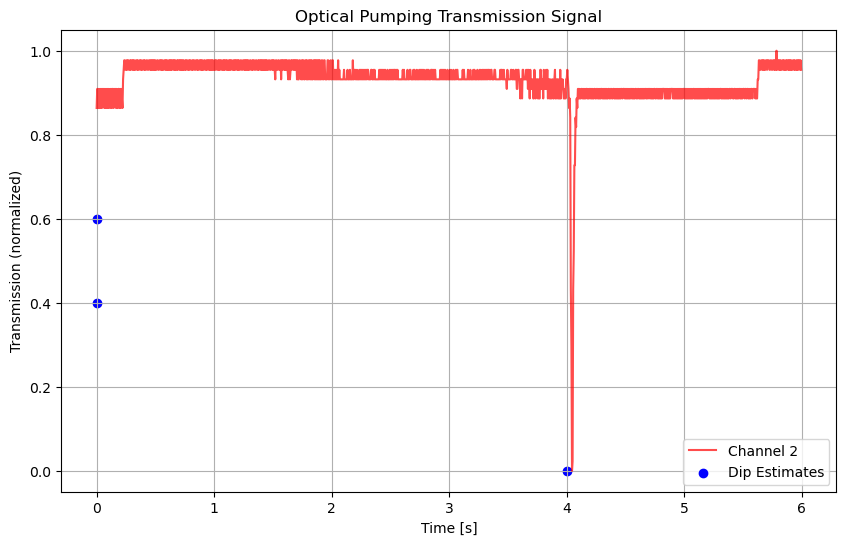

In [240]:
t0 = 0
nCut = (t0 // (time[1] - time[0])).astype(int)

time_cutFirst = time[nCut:] - t0
y2_norm_cutFirst = y2_norm[nCut:]

x0s = np.array([4,0,0])

m.plot_normalized_transmission(time_cutFirst, y2_norm_cutFirst, x0s, savename)


In [241]:
#    (A, h1, g1, x0_1, h2, g2, x0_2,  h3, g3, x0_3):
variables = ["A", "h1", "g1", "x0_1"]
p0 = (1, 1, 0.3, x0s[0])
lower_bound = (0,0,0,0)
upper_bound = (2,2,2,100)
bounds = [lower_bound, upper_bound]
popt, pcov = curve_fit(m.single_lorentz, time_cutFirst, y2_norm_cutFirst, p0=p0, bounds=bounds)
perr = np.sqrt(np.diag(pcov))
# popt, pcov = curve_fit(multi_lorentz, x, y2)
# print(popt)
for val, name in zip(popt,variables):
    print(name, val)

A 0.9351786247228147
h1 0.9871642042997023
g1 0.009417692033962302
x0_1 4.047010901717838


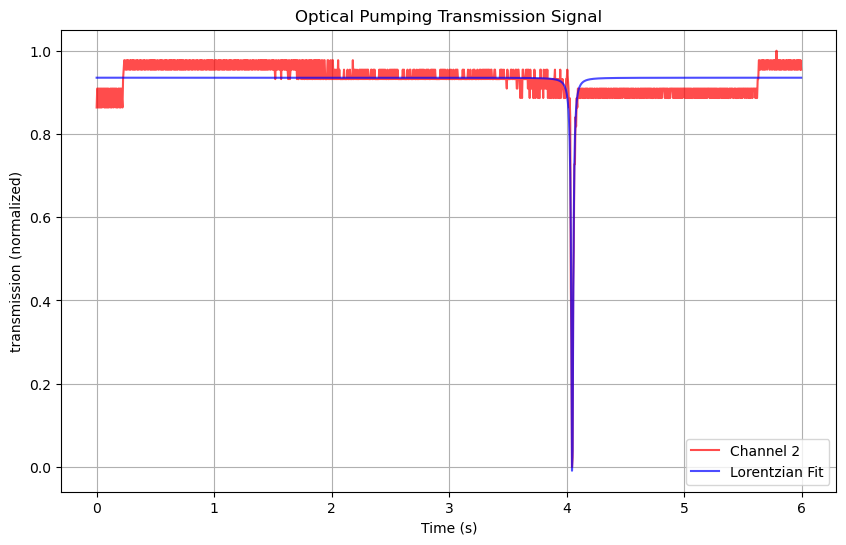

In [242]:
m.plot_fitted_transmission(time_cutFirst, y2_norm_cutFirst, popt, m.single_lorentz, "fit to " + savename)

In [243]:
x0_1_u = ufloat(popt[3], perr[3]) + t0

dt = time[1] - time[0]
x0_1_index = int(x0_1_u.n // dt)

numAvg = 10

# We treat the raw data y1 as having some inherent noise (e.g., std dev of the mean)
v_1 = ufloat(np.mean(y1[x0_1_index - numAvg : x0_1_index + numAvg]),
             np.std(y1[x0_1_index - numAvg : x0_1_index + numAvg]))


v_0 = ufloat(0.3,0.0034) # taken from 25kHz, though other frequencies were close (this isn't frequency dependent)

# Note: if there is uncertainty in the 0.6 factor, you should make it a ufloat too
VtoB = ufloat(0.6 * 10**(-4),0.6 * 10**(-4) / 100) * bAdjustment
VtoBHoriz = ufloat(1.705174,0.028108) / 1000
# VtoBHoriz = ufloat(1.775151,0.029249) / 1000

Rb_87 = (v_1 - v_0) * VtoB + vHoriz * VtoBHoriz

print(f"Rb87: {Rb_87:.3e} T")

Rb87: (9.738+/-0.182)e-05 T


In [244]:
vHoriz = 0.072
time, y1, y2, y2_norm = m.read_transmission_csv('./data/Mar 20 measurement/' + str(freq) + 'kHz_5s_72.csv')

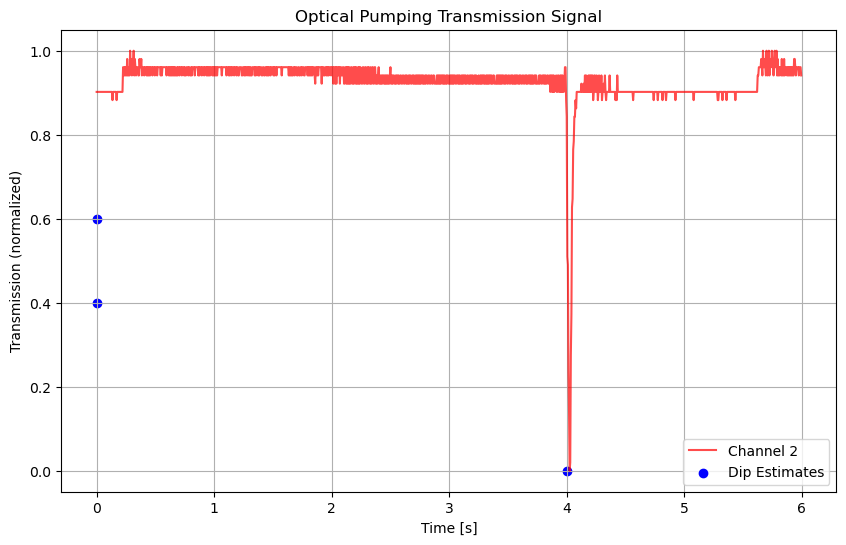

In [245]:
t0 = 0
nCut = (t0 // (time[1] - time[0])).astype(int)

time_cutFirst = time[nCut:] - t0
y2_norm_cutFirst = y2_norm[nCut:]

x0s = np.array([4,0,0])

m.plot_normalized_transmission(time_cutFirst, y2_norm_cutFirst, x0s, savename)

In [246]:
#    (A, h1, g1, x0_1, h2, g2, x0_2,  h3, g3, x0_3):
variables = ["A", "h1", "g1", "x0_1"]
p0 = (1, 1, 0.3, x0s[0])
lower_bound = (0,0,0,0)
upper_bound = (2,2,2,100)
bounds = [lower_bound, upper_bound]
popt, pcov = curve_fit(m.single_lorentz, time_cutFirst, y2_norm_cutFirst, p0=p0, bounds=bounds)
perr = np.sqrt(np.diag(pcov))
# popt, pcov = curve_fit(multi_lorentz, x, y2)
# print(popt)
for val, name in zip(popt,variables):
    print(name, val)

A 0.9335764985880388
h1 0.9799134737086443
g1 0.01367149688510399
x0_1 4.026022809459111


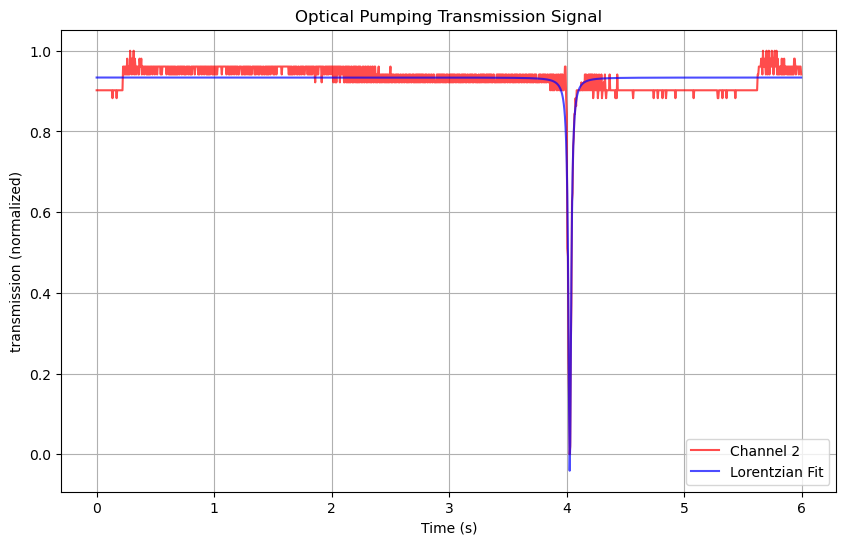

In [247]:
m.plot_fitted_transmission(time_cutFirst, y2_norm_cutFirst, popt, m.single_lorentz, "fit to " + savename)

In [248]:
x0_2_u = ufloat(popt[3], perr[3]) + t0

x0_2_index = int(x0_2_u.n // dt)

numAvg = 10

# We treat the raw data y1 as having some inherent noise (e.g., std dev of the mean)

v_2 = ufloat(np.mean(y1[x0_2_index - numAvg : x0_2_index + numAvg]),
             np.std(y1[x0_2_index - numAvg : x0_2_index + numAvg]))


Rb_85 = (v_2 - v_0) * VtoB + vHoriz * VtoBHoriz

print(f"Rb85: {Rb_85:.3e} T")

Rb85: (1.469+/-0.023)e-04 T


In [249]:
filepath = 'models/BFreqRatiosUncertain.csv'

m.append_to_v_ratio_csv(freq, Rb_87, Rb_85, filepath)